We're going to run a grid of stars from 5 to 9 solar masses for a range of metallicities to assess what masses lead to core-collapse in COSMIC.

In [21]:
from cosmic.sample.initialbinarytable import InitialBinaryTable
from cosmic.evolve import Evolve
import numpy as np
import matplotlib.pyplot as plt
import cogsworth
from multiprocessing import Pool
import pandas as pd

%config InlineBackend.figure_format = 'retina'

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

pd.set_option('display.max_columns', None)

In [22]:
mass_step = 0.025
mass_range = np.arange(5.8, 9 + mass_step, mass_step)

metallicity_grid = np.geomspace(1e-4, 0.03, 200)

M, Z = np.meshgrid(mass_range, metallicity_grid, indexing='ij')
m_flat = M.ravel()
z_flat = Z.ravel()
initial_binaries = InitialBinaryTable.InitialBinaries(
    m1=M.ravel(),
    m2=np.zeros(len(m_flat)),
    porb=-1 * np.ones(len(m_flat)),
    ecc=-1 * np.ones(len(m_flat)),
    tphysf=13700 * np.ones(len(m_flat)),
    kstar1=np.ones(len(m_flat)),
    kstar2=np.zeros(len(m_flat)),
    metallicity=z_flat,
)
len(initial_binaries)

25800

In [23]:
default_BSE_settings = cogsworth.utils.get_default_BSE_settings()
# default_BSE_settings["ecsn"] = 0
# default_BSE_settings["ecsn_mlow"] = 0
with Pool(32) as pool:
    bpp, bcm, initC, kick_info = Evolve.evolve(initial_binaries, pool=pool, BSEDict=default_BSE_settings,
                                               bpp_columns=["tphys", "mass_1", "mass_2", "massc_co_layer_1", "massc_he_layer_1", "evol_type", "kstar_1", "kstar_2", "SN_1", ])
final_bpp = bpp.drop_duplicates(subset="bin_num", keep="last")

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/cosmic/evolve.py:309: UserWarning: The value for binfrac in initial binary table is being overwritten by the value of binfrac from either the params file or the BSEDict.
  warnings.warn(


In [24]:
# find the minimum initial mass in initC where final_bpp has kstar_1 == 13
exploding_stars = final_bpp[(final_bpp["kstar_1"] == 13) & (final_bpp["SN_1"] == 1)]
exploding_initC = initC[initC["bin_num"].isin(exploding_stars["bin_num"])]
min_exploding_mass = exploding_initC.groupby("metallicity")["mass_1"].min().reset_index()

<Axes: title={'center': 'Minimum Initial Mass for Core-Collapse vs Metallicity'}, xlabel='Metallicity', ylabel='Minimum Initial Mass for Core-Collapse (M$_\\odot$)'>

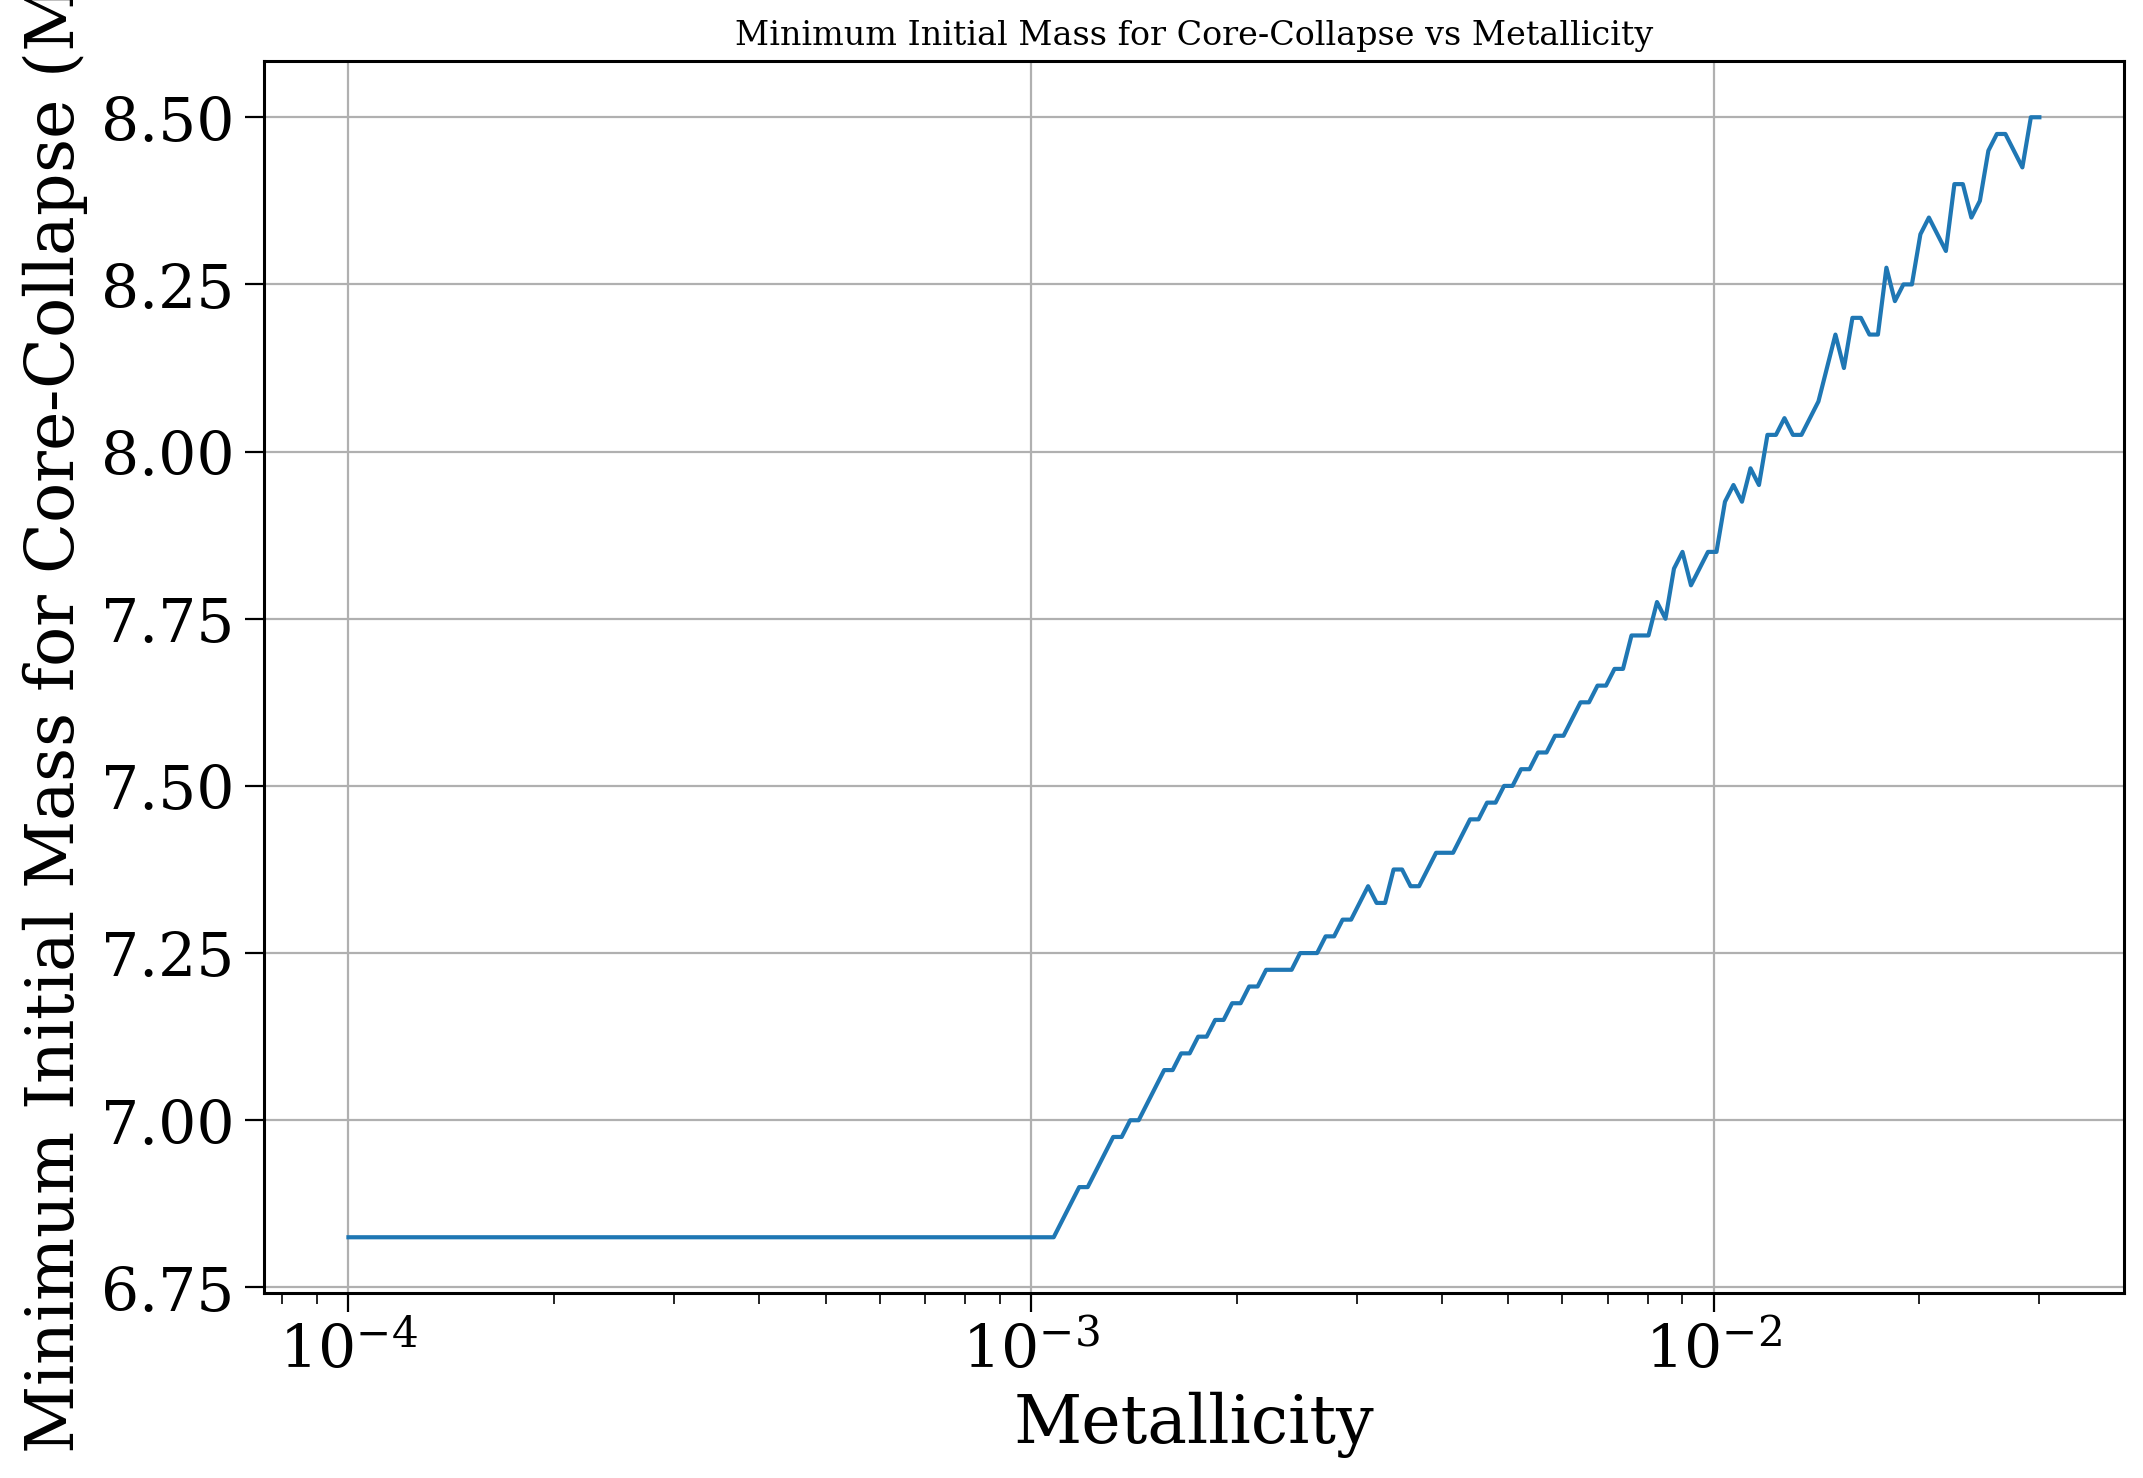

In [25]:
min_exploding_mass.plot(
    x="metallicity",
    y="mass_1",
    logx=True,
    xlabel="Metallicity",
    ylabel="Minimum Initial Mass for Core-Collapse (M$_\odot$)",
    title="Minimum Initial Mass for Core-Collapse vs Metallicity",
    legend=False,
    grid=True,
)

In [26]:
min_exploding_mass.to_hdf("~/ceph/underworld/cosmic_explode_crit.h5", key="min_exploding_mass", mode="w")

In [27]:
np.log10(3e-4) * 0.8 + 9.2

np.float64(6.381697003775729)

In [ ]:
default_BSE_settings

{'pts1': 0.001,
 'pts2': 0.01,
 'pts3': 0.02,
 'zsun': 0.014,
 'windflag': 3,
 'eddlimflag': 0,
 'neta': 0.5,
 'bwind': 0.0,
 'hewind': 0.5,
 'beta': 0.125,
 'xi': 0.5,
 'acc2': 1.5,
 'LBV_flag': 1,
 'alpha1': 1.0,
 'lambdaf': 0.0,
 'ceflag': 1,
 'cekickflag': 2,
 'cemergeflag': 1,
 'cehestarflag': 0,
 'qcflag': 5,
 'qcrit_array': [0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'kickflag': 5,
 'sigma': 265.0,
 'bhflag': 1,
 'bhsigmafrac': 1.0,
 'sigmadiv': -20.0,
 'ecsn': 2.25,
 'ecsn_mlow': 1.6,
 'aic': 1,
 'ussn': 1,
 'polar_kick_angle': 90.0,
 'natal_kick_array': [[-100.0, -100.0, -100.0, -100.0, 0.0],
  [-100.0, -100.0, -100.0, -100.0, 0.0]],
 'mm_mu_ns': 400.0,
 'mm_mu_bh': 200.0,
 'remnantflag': 4,
 'fryer_mass_limit': 0,
 'mxns': 3.0,
 'rembar_massloss': 0.5,
 'wd_mass_lim': 1,
 'maltsev_mode': 0,
 'maltsev_fallback': 0.5,
 'maltsev_pf_prob': 0.1,
 'pisn': -2,
 'ppi_co_shift': 0.0,
 'ppi_extra_ml': 0.0,
 'bhspinfla

/tmp/ipykernel_1160930/395999991.py:29: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


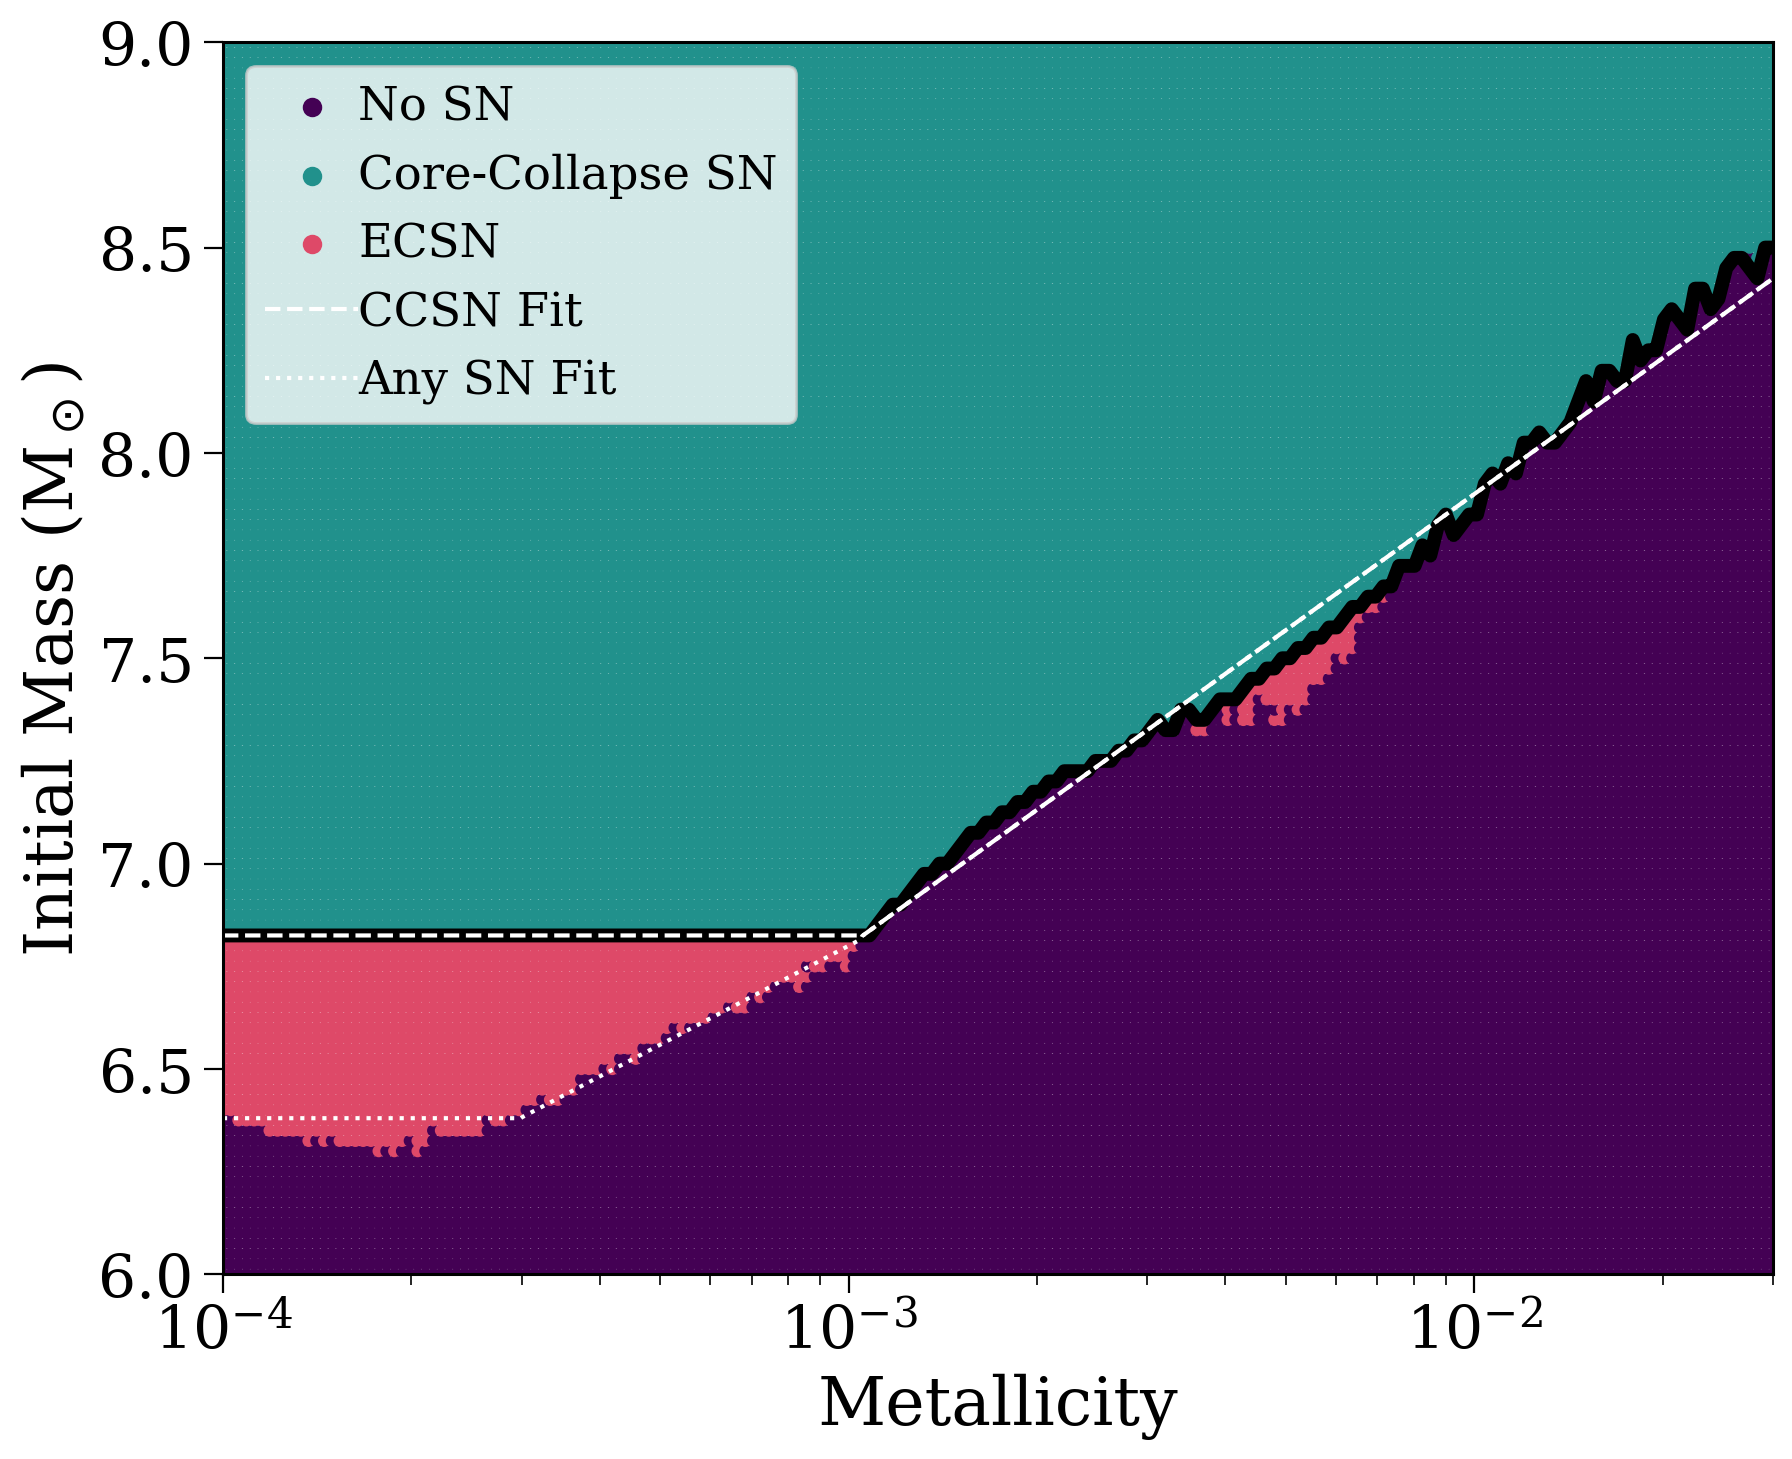

In [28]:
fig, ax = plt.subplots(figsize=(10, 8))

colours = final_bpp["SN_1"].map({0: plt.get_cmap("viridis")(0), 1: plt.get_cmap("viridis")(0.5), 2: plt.get_cmap("magma")(0.6)}).values

ax.scatter(initC["metallicity"], initC["mass_1"],
           c=colours,
           s=12,
           rasterized=True)

ax.plot(min_exploding_mass["metallicity"], min_exploding_mass["mass_1"],
        c='black', lw=5)

# ax.axhspan(max(mass_range) + mass_step, 100, color=cogsworth.utils.kstar_translator[13]["colour"])
# ax.axhspan(0, min(mass_range) - mass_step, color=cogsworth.utils.kstar_translator[12]["colour"])

# ax.annotate('No Core-Collapse', xy=(0.5, 0.01), xycoords='axes fraction',
#             fontsize=0.5*fs, color='white', ha='center', va='bottom')
# ax.annotate('All Core-Collapse', xy=(0.5, 0.99), xycoords='axes fraction',
#             fontsize=0.5*fs, color='white', ha='center', va='top')

# for k in np.unique(final_bpp['kstar_1']):
#     ax.scatter(
#         np.nan, np.nan,
#         c=cogsworth.utils.kstar_translator[k]["colour"],
#         label=cogsworth.utils.kstar_translator[k]["short"],
#     )

for sn_type, color in zip([0, 1, 2], [plt.get_cmap("viridis")(0), plt.get_cmap("viridis")(0.5), plt.get_cmap("magma")(0.6)]):
    ax.scatter(
        np.nan, np.nan,
        c=color,
        label={0: "No SN", 1: "Core-Collapse SN", 2: "ECSN"}[sn_type],
    )


Z_range = np.geomspace(1e-4, 0.03, 1000)
line = np.log10(Z_range) * 1.1 + 10.1
line[Z_range < 1.05e-3] = 6.825
plt.plot(Z_range, line, c='white', ls='--', label="CCSN Fit")

line = np.log10(Z_range) * 1.1 + 10.1
line[(Z_range < 1.05e-3)] = np.log10(Z_range)[(Z_range < 1.05e-3)] * 0.8 + 9.2
line[Z_range < 3e-4] = 6.38
plt.plot(Z_range, line, c='white', ls=':', label="Any SN Fit")

ax.legend(loc='upper left', handletextpad=0.0)

ax.set(
    xlabel="Metallicity",
    ylabel="Initial Mass (M$_\odot$)",
    xscale="log",
    xlim=(1e-4, 0.03),
    ylim=(6, 9),
)

# draw a box around everything with 6.9 < mass_1 < 7.1 and 0.6e-3 < metallicity < 1e-3
# ax.plot([0.6e-3, 1e-3, 1e-3, 0.6e-3, 0.6e-3], [6.9, 6.9, 7.1, 7.1, 6.9], c='white', ls='-', lw=2)

# plt.savefig("../plots/cosmic_explode_crit.pdf", format="pdf", bbox_inches='tight')
plt.show()

In [29]:
# get everything with 6.9 < mass_1 < 7.1 and 0.8e-3 < metallicity < 1e-3
box = initC[(initC["mass_1"] > 6.9) & (initC["mass_1"] < 7.1) & (initC["metallicity"] > 0.6e-3) & (initC["metallicity"] < 1e-3)]
box_nums = box["bin_num"].values

In [30]:
bpp.loc[box_nums[3]]

,tphys,mass_1,mass_2,massc_co_layer_1,massc_he_layer_1,evol_type,kstar_1,kstar_2,SN_1,bin_num
8866,0.000000,6.900000,0.0,0.000000,0.000000,1,1,0,0,8866
8866,48.788842,6.894450,0.0,0.000000,1.303046,2,2,0,0,8866
8866,48.984901,6.893403,0.0,0.000000,1.328876,2,3,0,0,8866
8866,49.001841,6.892957,0.0,0.000000,1.329928,2,4,0,0,8866
8866,54.294788,6.789234,0.0,1.132945,1.114110,2,5,0,0,8866
8866,54.470622,6.754856,0.0,1.436704,0.000000,2,6,0,0,8866
8866,54.531195,6.718585,0.0,1.440000,0.000000,15,6,0,1,8866
8866,54.531195,1.260782,0.0,0.000000,0.000000,2,13,0,1,8866
8866,13700.000000,1.260782,0.0,0.000000,0.000000,10,13,0,1,8866


In [31]:
box["dtp"] = 0.0
box["tphysf"] = 100
with Pool(32) as pool:
    bpp, bcm, initC, kick_info = Evolve.evolve(box, pool=pool,
                                               dtp=0,
                                               bpp_columns=["tphys", "mass_1", "mass_2", "massc_co_layer_1", "massc_he_layer_1", "evol_type", "kstar_1", "kstar_2", "SN_1", ])

/tmp/ipykernel_1160930/222729130.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  box["dtp"] = 0.0
/tmp/ipykernel_1160930/222729130.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  box["tphysf"] = 100


In [32]:
bcm.loc[box_nums[0]]

,tphys,kstar_1,mass0_1,mass_1,lum_1,rad_1,teff_1,massc_he_layer_1,massc_co_layer_1,radc_1,menv_1,renv_1,epoch_1,omega_spin_1,deltam_1,RRLO_1,kstar_2,mass0_2,mass_2,lum_2,rad_2,teff_2,massc_he_layer_2,massc_co_layer_2,radc_2,menv_2,renv_2,epoch_2,omega_spin_2,deltam_2,RRLO_2,porb,sep,ecc,B_1,B_2,SN_1,SN_2,bin_state,merger_type,bin_num
8863,0.000000,1,6.900000,6.900000,1862.807435,2.300651,25112.283507,0.0,0.0,0.000000,1.000000e-10,1.000000e-10,0.000000e+00,4.732376e+03,0.000000e+00,0.0001,0,0.0,0.0,9.348009e-09,0.306707,102.940875,0.0,0.0,0.0,0.005,0.199359,0.0,4.334700e-13,0.0,3.067066e-11,0.0,0.0,-1.0,0.000000e+00,0.0,0,0,-1,-001,8863
8863,0.048639,1,6.900000,6.900000,1863.569280,2.301612,25109.606894,0.0,0.0,0.000000,1.000000e-10,1.000000e-10,0.000000e+00,4.728423e+03,-7.765574e-12,0.0001,0,0.0,0.0,9.348009e-09,0.306707,102.940875,0.0,0.0,0.0,0.005,0.199359,0.0,4.334700e-13,0.0,3.067066e-11,0.0,0.0,-1.0,0.000000e+00,0.0,0,0,-1,-001,8863
8863,0.097278,1,6.899999,6.899999,1864.333638,2.302574,25106.937955,0.0,0.0,0.000000,1.000000e-10,1.000000e-10,-4.889746e-09,4.724473e+03,-7.768114e-12,0.0001,0,0.0,0.0,9.348009e-09,0.306707,102.940875,0.0,0.0,0.0,0.005,0.199359,0.0,4.334700e-13,0.0,3.067066e-11,0.0,0.0,-1.0,0.000000e+00,0.0,0,0,-1,-001,8863
8863,0.145918,1,6.899999,6.899999,1865.100512,2.303536,25104.276668,0.0,0.0,0.000000,1.000000e-10,1.000000e-10,-1.467248e-08,4.720526e+03,-7.770687e-12,0.0001,0,0.0,0.0,9.348009e-09,0.306707,102.940875,0.0,0.0,0.0,0.005,0.199359,0.0,4.334700e-13,0.0,3.067066e-11,0.0,0.0,-1.0,0.000000e+00,0.0,0,0,-1,-001,8863
8863,0.194557,1,6.899998,6.899998,1865.869905,2.304498,25101.623006,0.0,0.0,0.000000,1.000000e-10,1.000000e-10,-2.935150e-08,4.716583e+03,-7.773291e-12,0.0001,0,0.0,0.0,9.348009e-09,0.306707,102.940875,0.0,0.0,0.0,0.005,0.199359,0.0,4.334700e-13,0.0,3.067066e-11,0.0,0.0,-1.0,0.000000e+00,0.0,0,0,-1,-001,8863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8863,55.423034,13,6.893779,1.277584,0.019477,0.000014,578877.884359,0.0,0.0,0.000014,1.000000e-10,1.000000e-10,5.432303e+01,2.304964e+08,-6.792692e-46,0.0001,0,0.0,0.0,9.348009e-09,0.306707,102.940875,0.0,0.0,0.0,0.005,0.199359,0.0,4.334700e-13,0.0,3.067066e-11,0.0,0.0,-1.0,4.390930e+11,0.0,1,0,-1,-001,8863
8863,65.423034,13,6.893779,1.277584,0.000191,0.000014,182230.812334,0.0,0.0,0.000014,1.000000e-10,1.000000e-10,5.432303e+01,2.192608e+08,-8.606067e-35,0.0001,0,0.0,0.0,9.348009e-09,0.306707,102.940875,0.0,0.0,0.0,0.005,0.199359,0.0,4.334700e-13,0.0,3.067066e-11,0.0,0.0,-1.0,4.389467e+11,0.0,1,0,-1,-001,8863
8863,88.245824,13,6.893779,1.277584,0.000020,0.000014,104240.747281,0.0,0.0,0.000014,1.000000e-10,1.000000e-10,5.432303e+01,1.973347e+08,-1.077672e-29,0.0001,0,0.0,0.0,9.348009e-09,0.306707,102.940875,0.0,0.0,0.0,0.005,0.199359,0.0,4.334700e-13,0.0,3.067066e-11,0.0,0.0,-1.0,4.374861e+11,0.0,1,0,-1,-001,8863
8863,100.000000,13,6.893779,1.277584,0.000011,0.000014,89832.745949,0.0,0.0,0.000014,1.000000e-10,1.000000e-10,5.432303e+01,1.892269e+08,-3.339737e-29,0.0001,0,0.0,0.0,9.348009e-09,0.306707,102.940875,0.0,0.0,0.0,0.005,0.199359,0.0,4.334700e-13,0.0,3.067066e-11,0.0,0.0,-1.0,4.341709e+11,0.0,1,0,-1,-001,8863


In [33]:
bcm.loc[8866][bcm.loc[8866]["tphys"] > 54.4]

,tphys,kstar_1,mass0_1,mass_1,lum_1,rad_1,teff_1,massc_he_layer_1,massc_co_layer_1,radc_1,menv_1,renv_1,epoch_1,omega_spin_1,deltam_1,RRLO_1,kstar_2,mass0_2,mass_2,lum_2,rad_2,teff_2,massc_he_layer_2,massc_co_layer_2,radc_2,menv_2,renv_2,epoch_2,omega_spin_2,deltam_2,RRLO_2,porb,sep,ecc,B_1,B_2,SN_1,SN_2,bin_state,merger_type,bin_num
8866,54.401340,5,6.893403,6.776865,22074.182012,296.934131,4.101198e+03,0.974552,1.272503,1.618133,4.529811e+00,2.953160e+02,-0.062108,2.769486e-01,-1.853173e-07,0.0001,0,0.0,0.0,9.196178e-09,0.306659,102.528274,0.0,0.0,0.0,0.005,0.199328,0.0,4.335373e-13,0.0,3.066589e-11,0.0,0.0,-1.0,0.000000e+00,0.0,0,0,-1,-001,8866
8866,54.404943,5,6.893403,6.776168,22638.728158,302.195512,4.091086e+03,0.968108,1.278946,1.768575,4.529114e+00,3.004269e+02,-0.062108,2.671545e-01,-1.934398e-07,0.0001,0,0.0,0.0,9.196178e-09,0.306659,102.528274,0.0,0.0,0.0,0.005,0.199328,0.0,4.335373e-13,0.0,3.066589e-11,0.0,0.0,-1.0,0.000000e+00,0.0,0,0,-1,-001,8866
8866,54.408473,5,6.893403,6.775455,23217.712545,307.556511,4.080957e+03,0.961632,1.285422,1.940230,4.528401e+00,3.056163e+02,-0.062108,2.576906e-01,-2.019230e-07,0.0001,0,0.0,0.0,9.196178e-09,0.306659,102.528274,0.0,0.0,0.0,0.005,0.199328,0.0,4.335373e-13,0.0,3.066589e-11,0.0,0.0,-1.0,0.000000e+00,0.0,0,0,-1,-001,8866
8866,54.411934,5,6.893403,6.774726,23811.504430,313.019134,4.070810e+03,0.955124,1.291931,2.136669,4.527671e+00,3.108825e+02,-0.062108,2.485461e-01,-2.107831e-07,0.0001,0,0.0,0.0,9.196178e-09,0.306659,102.528274,0.0,0.0,0.0,0.005,0.199328,0.0,4.335373e-13,0.0,3.066589e-11,0.0,0.0,-1.0,0.000000e+00,0.0,0,0,-1,-001,8866
8866,54.415325,5,6.893403,6.773980,24420.482514,318.585427,4.060647e+03,0.948582,1.298472,2.362148,4.526925e+00,3.162233e+02,-0.062108,2.397106e-01,-2.200371e-07,0.0001,0,0.0,0.0,9.196178e-09,0.306659,102.528274,0.0,0.0,0.0,0.005,0.199328,0.0,4.335373e-13,0.0,3.066589e-11,0.0,0.0,-1.0,0.000000e+00,0.0,0,0,-1,-001,8866
8866,54.418648,5,6.893403,6.773216,25045.035183,324.257480,4.050466e+03,0.942007,1.305047,2.621754,4.526162e+00,3.216357e+02,-0.062108,2.311741e-01,-2.297028e-07,0.0001,0,0.0,0.0,9.196178e-09,0.306659,102.528274,0.0,0.0,0.0,0.005,0.199328,0.0,4.335373e-13,0.0,3.066589e-11,0.0,0.0,-1.0,0.000000e+00,0.0,0,0,-1,-001,8866
8866,54.421905,5,6.893403,6.772435,25685.560756,330.037427,4.040269e+03,0.935399,1.311655,2.921589,4.525381e+00,3.271158e+02,-0.062108,2.229267e-01,-2.397986e-07,0.0001,0,0.0,0.0,9.196178e-09,0.306659,102.528274,0.0,0.0,0.0,0.005,0.199328,0.0,4.335373e-13,0.0,3.066589e-11,0.0,0.0,-1.0,0.000000e+00,0.0,0,0,-1,-001,8866
8866,54.425096,5,6.893403,6.771636,26342.467741,335.927447,4.030055e+03,0.928758,1.318297,3.268994,4.524582e+00,3.326585e+02,-0.062108,2.149588e-01,-2.503441e-07,0.0001,0,0.0,0.0,9.196178e-09,0.306659,102.528274,0.0,0.0,0.0,0.005,0.199328,0.0,4.335373e-13,0.0,3.066589e-11,0.0,0.0,-1.0,0.000000e+00,0.0,0,0,-1,-001,8866
8866,54.428224,5,6.893403,6.770819,27016.175090,341.929768,4.019825e+03,0.922083,1.324972,3.672830,4.523765e+00,3.382569e+02,-0.062108,2.072612e-01,-2.613595e-07,0.0001,0,0.0,0.0,9.196178e-09,0.306659,102.528274,0.0,0.0,0.0,0.005,0.199328,0.0,4.335373e-13,0.0,3.066589e-11,0.0,0.0,-1.0,0.000000e+00,0.0,0,0,-1,-001,8866
8866,54.431289,5,6.893403,6.769982,27707.112472,348.046661,4.009578e+03,0.915374,1.331681,4.143832,4.522928e+00,3.439028e+02,-0.062108,1.998250e-01,-2.728661e-07,0.0001,0,0.0,0.0,9.196178e-09,0.306659,102.528274,0.0,0.0,0.0,0.005,0.199328,0.0,4.335373e-13,0.0,3.066589e-11,0.0,0.0,-1.0,0.000000e+00,0.0,0,0,-1,-001,8866


In [34]:
bcm[bcm["massc_co_layer_1"] > bcm["mass_1"]]

,tphys,kstar_1,mass0_1,mass_1,lum_1,rad_1,teff_1,massc_he_layer_1,massc_co_layer_1,radc_1,menv_1,renv_1,epoch_1,omega_spin_1,deltam_1,RRLO_1,kstar_2,mass0_2,mass_2,lum_2,rad_2,teff_2,massc_he_layer_2,massc_co_layer_2,radc_2,menv_2,renv_2,epoch_2,omega_spin_2,deltam_2,RRLO_2,porb,sep,ecc,B_1,B_2,SN_1,SN_2,bin_state,merger_type,bin_num


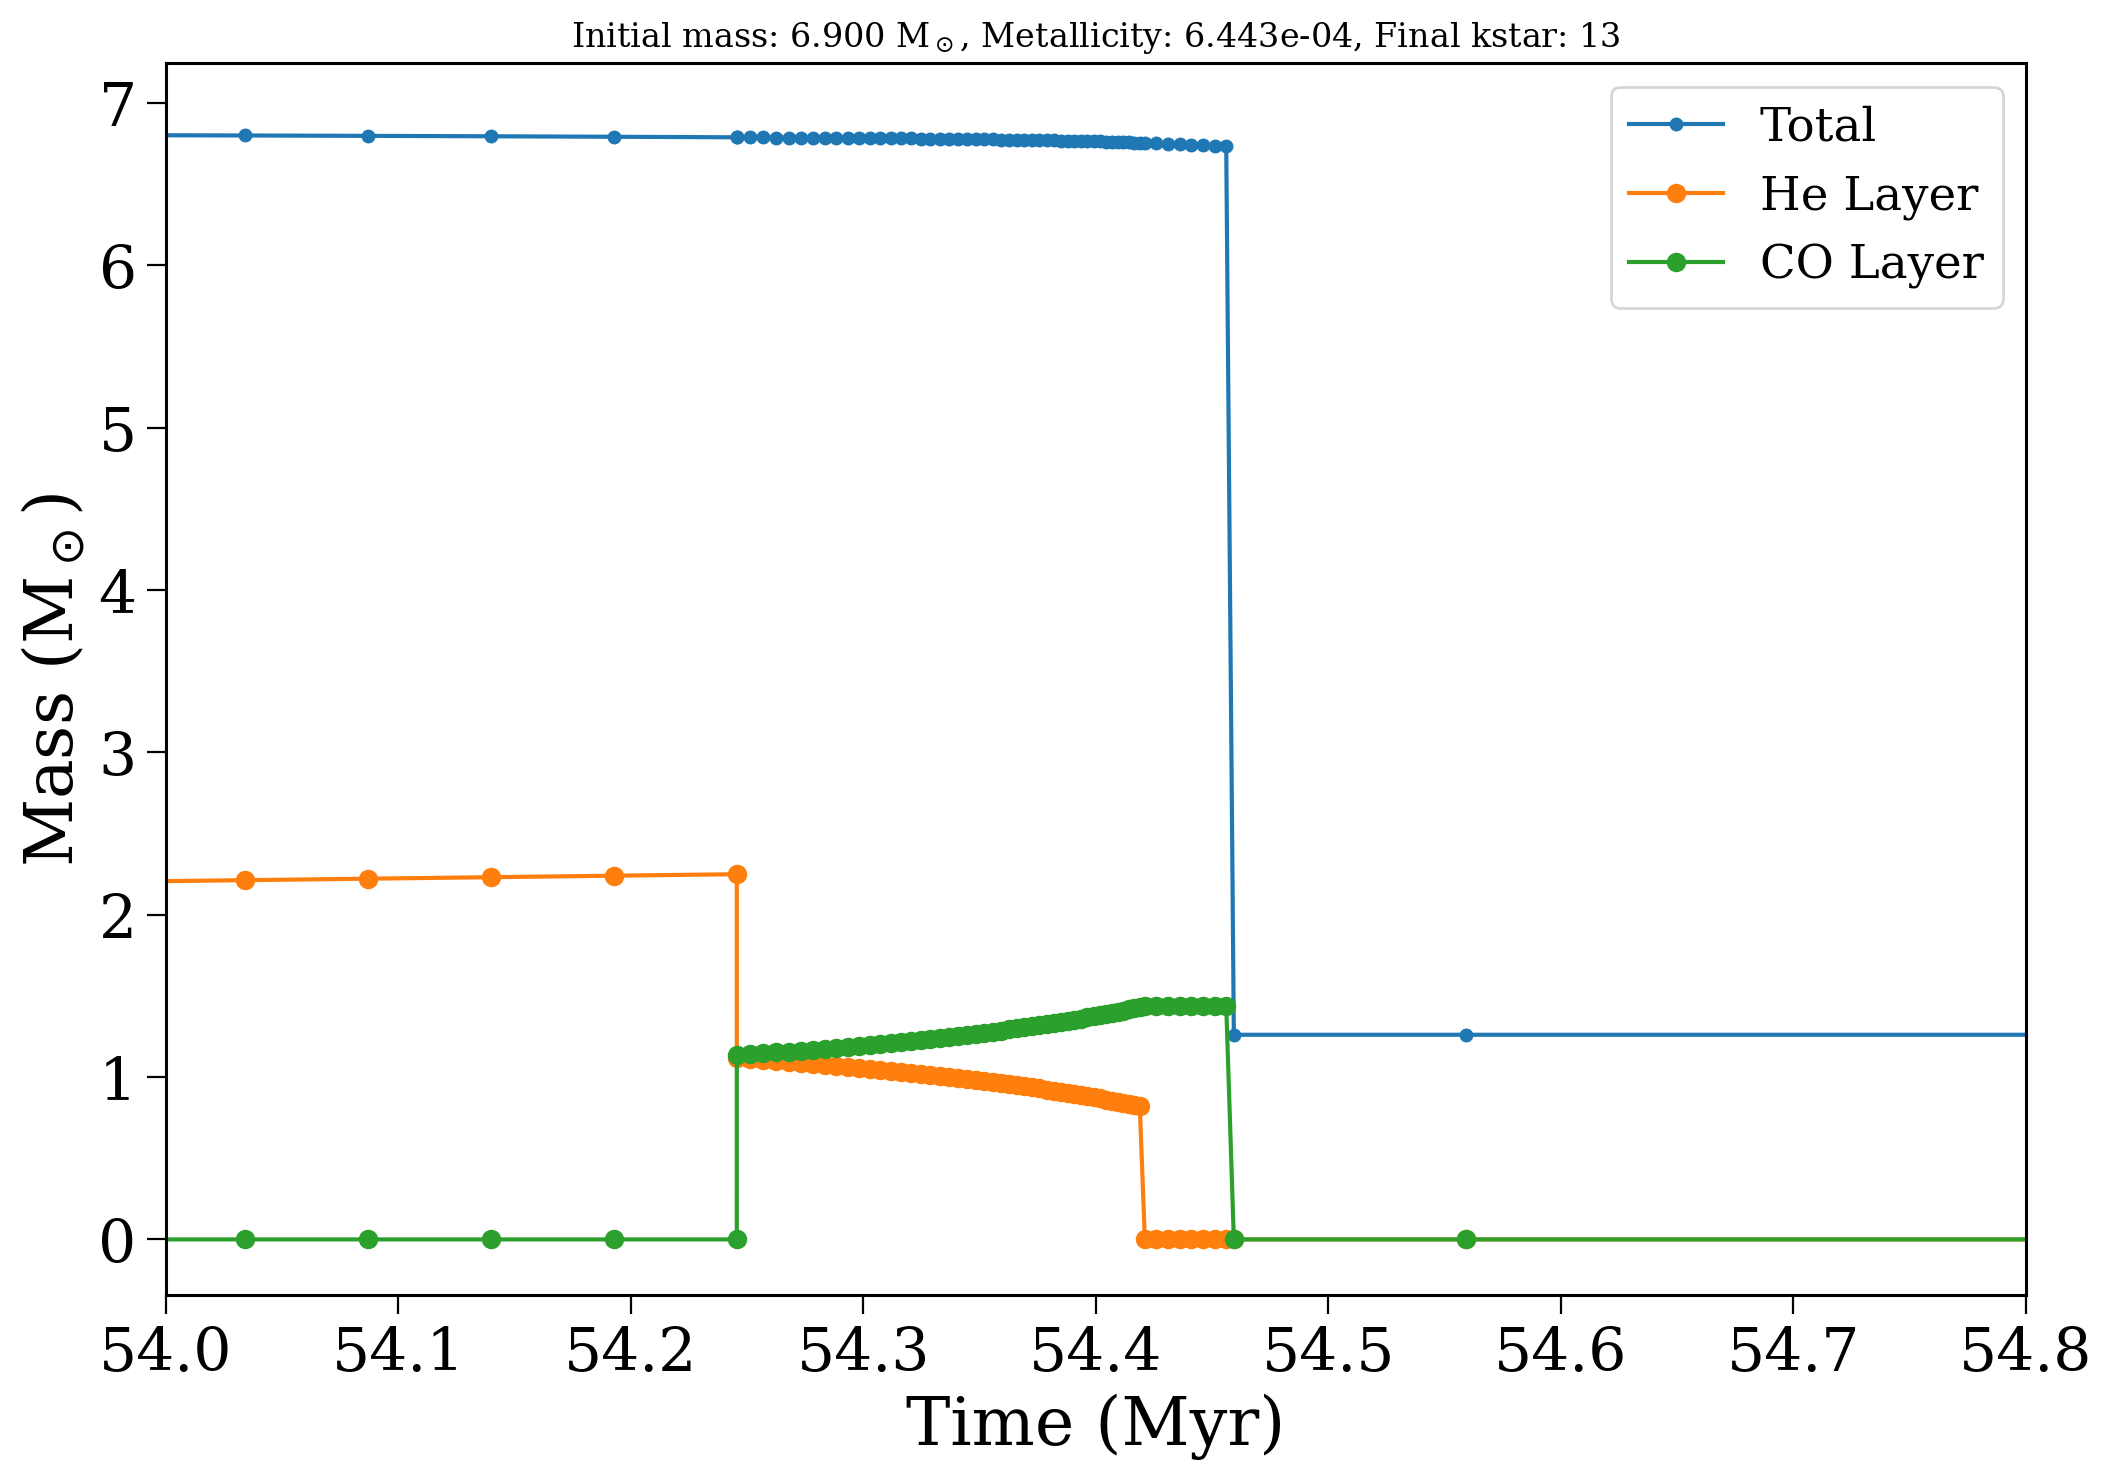

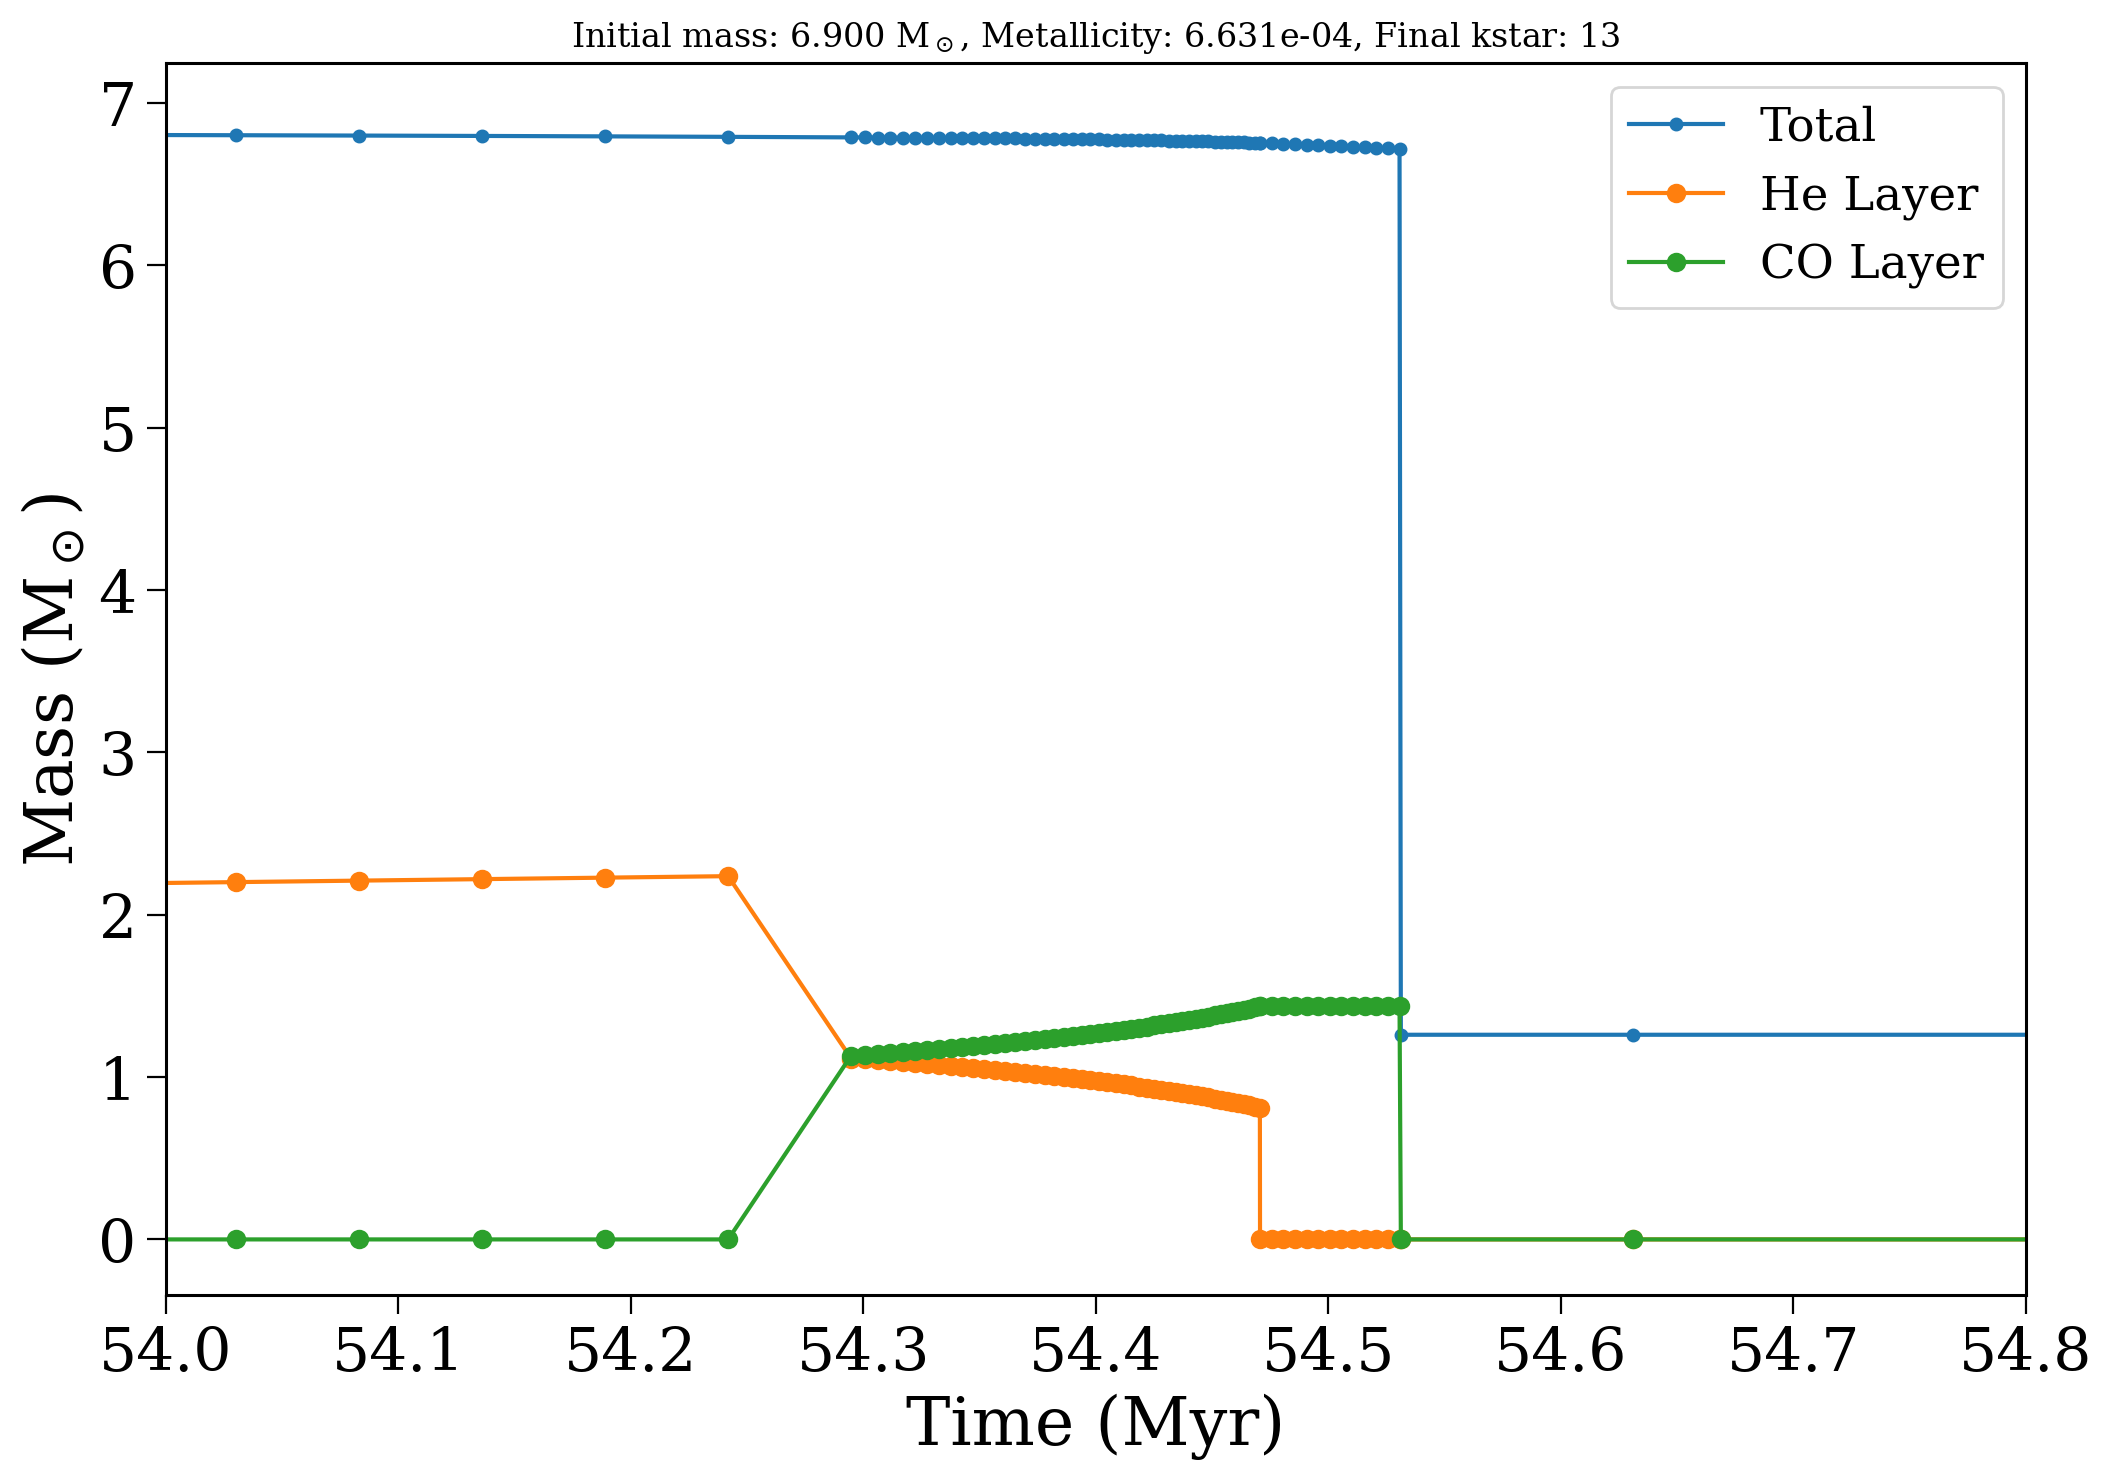

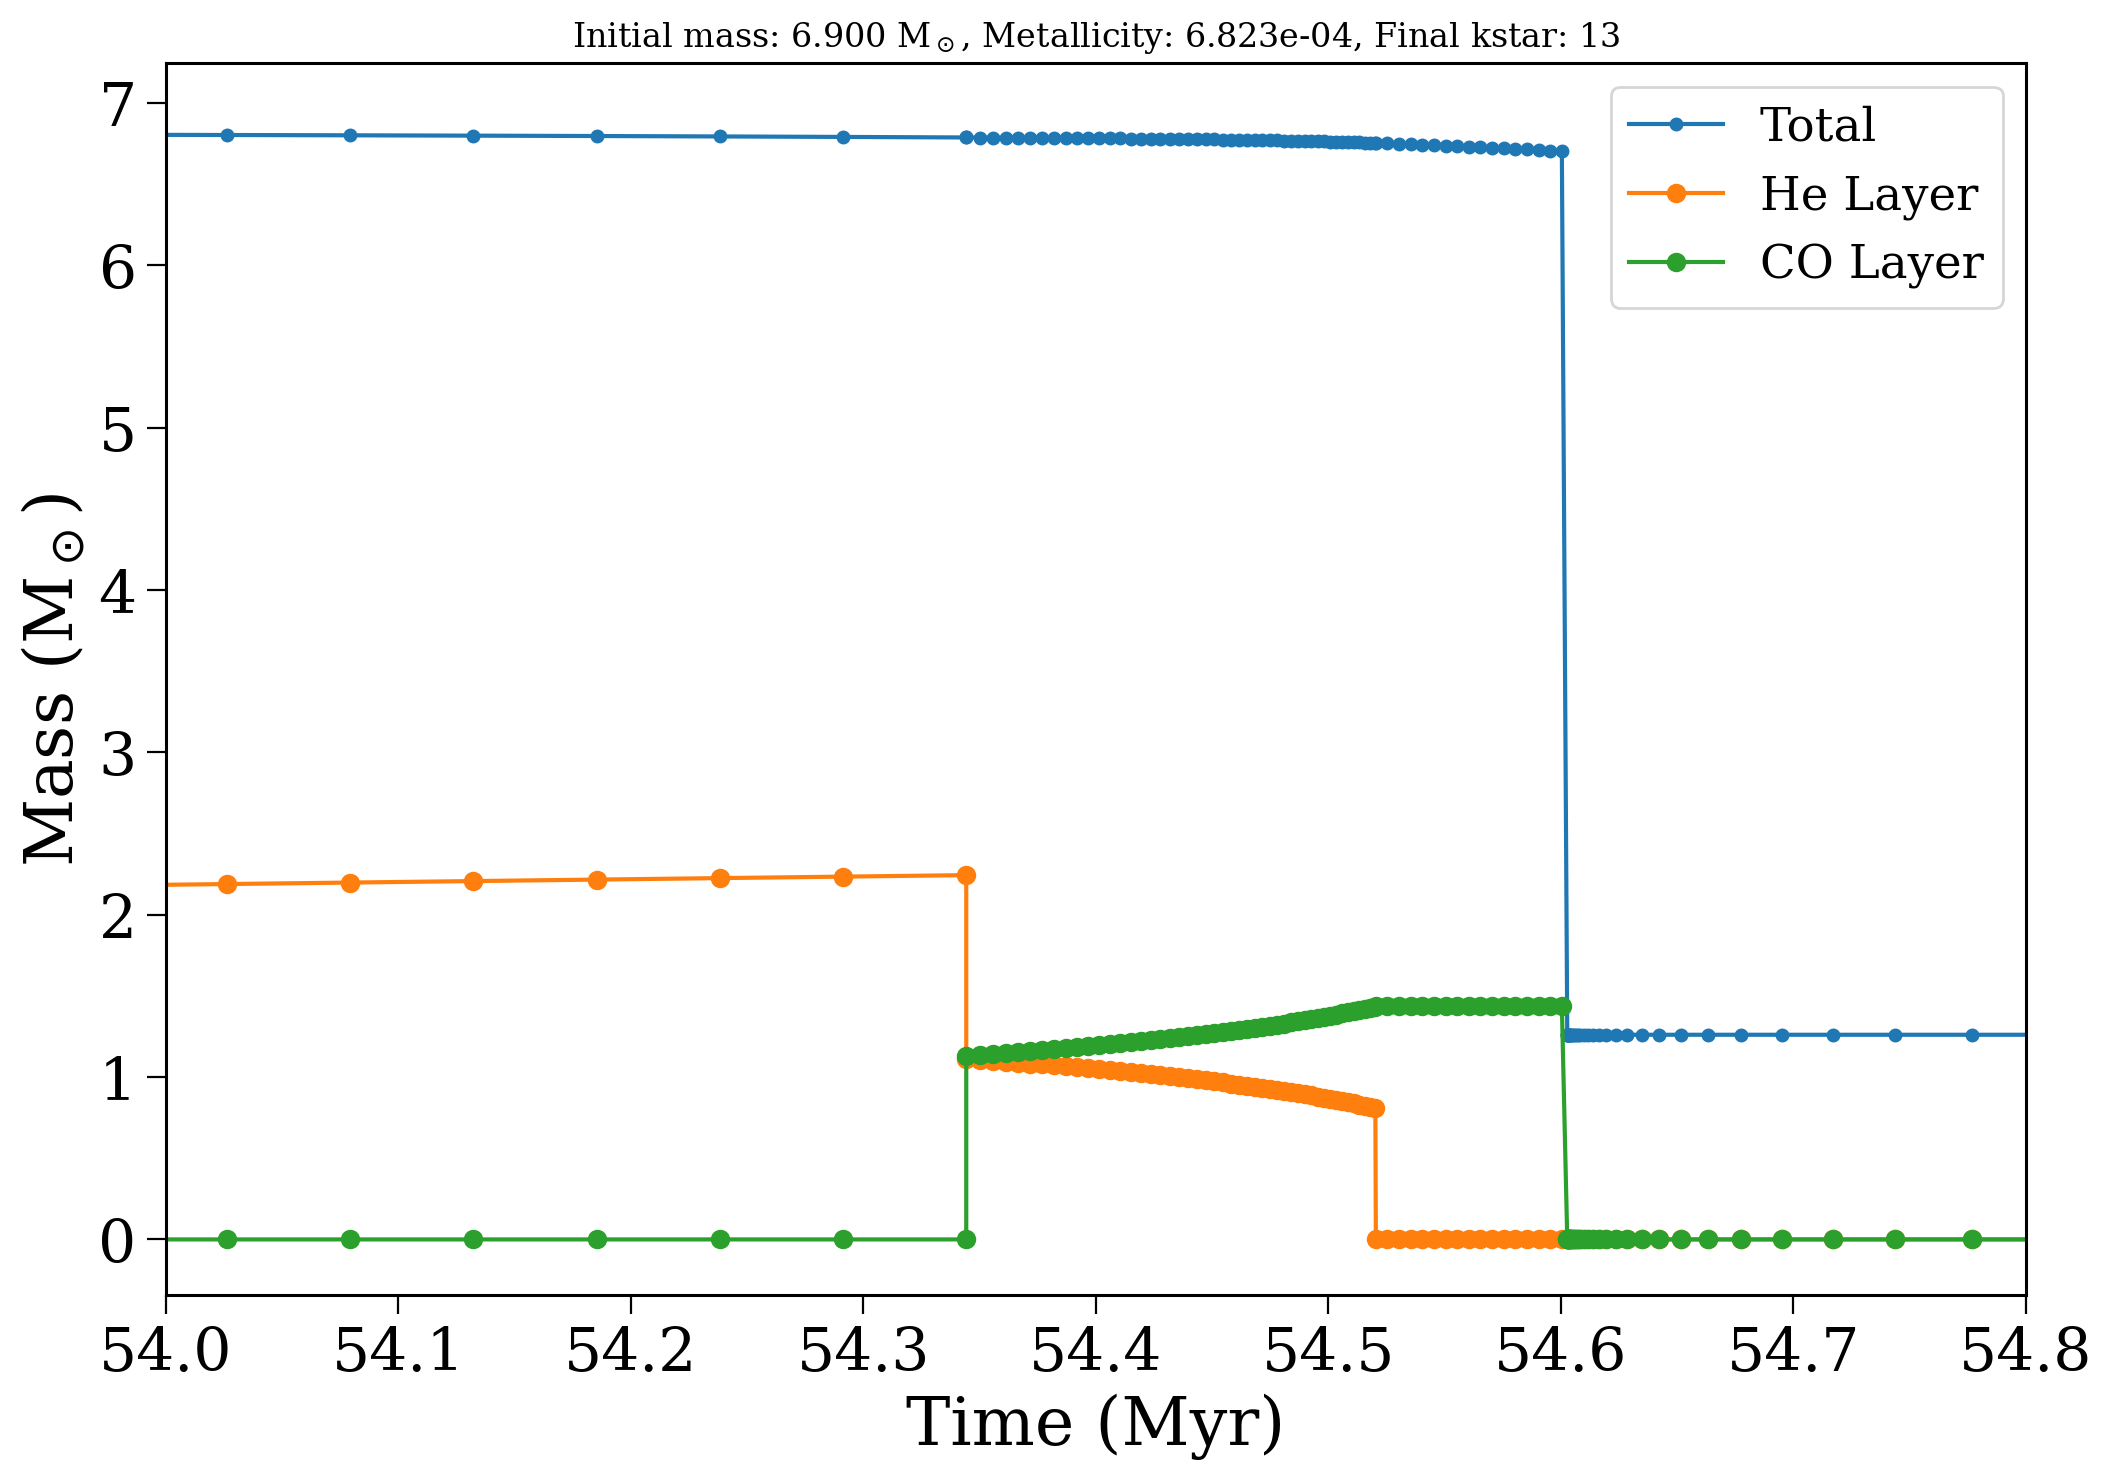

In [35]:
for i in [2, 3, 4]:
    plt.plot(bcm.loc[box_nums[i]]["tphys"], bcm.loc[box_nums[i]]["mass_1"], marker='o', markersize=4, label="Total")
    plt.plot(bcm.loc[box_nums[i]]["tphys"], bcm.loc[box_nums[i]]["massc_he_layer_1"], label="He Layer", marker='o')
    plt.plot(bcm.loc[box_nums[i]]["tphys"], bcm.loc[box_nums[i]]["massc_co_layer_1"], label="CO Layer", marker='o')
    plt.xlim(54, 54.8)
    plt.title(f"Initial mass: {box.loc[box_nums[i], 'mass_1']:.3f} M$_\odot$, Metallicity: {box.loc[box_nums[i], 'metallicity']:.3e}, Final kstar: {bcm.loc[box_nums[i], 'kstar_1'].iloc[-1]}")
    plt.legend()
    plt.xlabel("Time (Myr)")
    plt.ylabel("Mass (M$_\odot$)")
    plt.show()

In [36]:
bpp.loc[box["bin_num"].values[2]]

,tphys,mass_1,mass_2,massc_co_layer_1,massc_he_layer_1,evol_type,kstar_1,kstar_2,SN_1,bin_num
8865,0.000000,6.900000,0.0,0.000000,0.000000,1,1,0,0,8865
8865,48.745946,6.894590,0.0,0.000000,1.303086,2,2,0,0,8865
8865,48.942223,6.893531,0.0,0.000000,1.328914,2,3,0,0,8865
8865,48.958882,6.893089,0.0,0.000000,1.329963,2,4,0,0,8865
8865,54.245584,6.789745,0.0,1.134324,1.115586,2,5,0,0,8865
8865,54.421083,6.755388,0.0,1.437960,0.000000,2,6,0,0,8865
8865,54.459357,6.733330,0.0,1.440000,0.000000,15,6,0,1,8865
8865,54.459357,1.260782,0.0,0.000000,0.000000,2,13,0,1,8865
8865,100.000000,1.260782,0.0,0.000000,0.000000,10,13,0,1,8865


In [37]:
bpp.loc[box["bin_num"].values[3]]

,tphys,mass_1,mass_2,massc_co_layer_1,massc_he_layer_1,evol_type,kstar_1,kstar_2,SN_1,bin_num
8866,0.000000,6.900000,0.0,0.000000,0.000000,1,1,0,0,8866
8866,48.788842,6.894450,0.0,0.000000,1.303046,2,2,0,0,8866
8866,48.984901,6.893403,0.0,0.000000,1.328876,2,3,0,0,8866
8866,49.001841,6.892957,0.0,0.000000,1.329928,2,4,0,0,8866
8866,54.294788,6.789234,0.0,1.132945,1.114110,2,5,0,0,8866
8866,54.470622,6.754856,0.0,1.436704,0.000000,2,6,0,0,8866
8866,54.531195,6.718585,0.0,1.440000,0.000000,15,6,0,1,8866
8866,54.531195,1.260782,0.0,0.000000,0.000000,2,13,0,1,8866
8866,100.000000,1.260782,0.0,0.000000,0.000000,10,13,0,1,8866


ValueError: 'c' argument has 25800 elements, which is inconsistent with 'x' and 'y' with size 144.

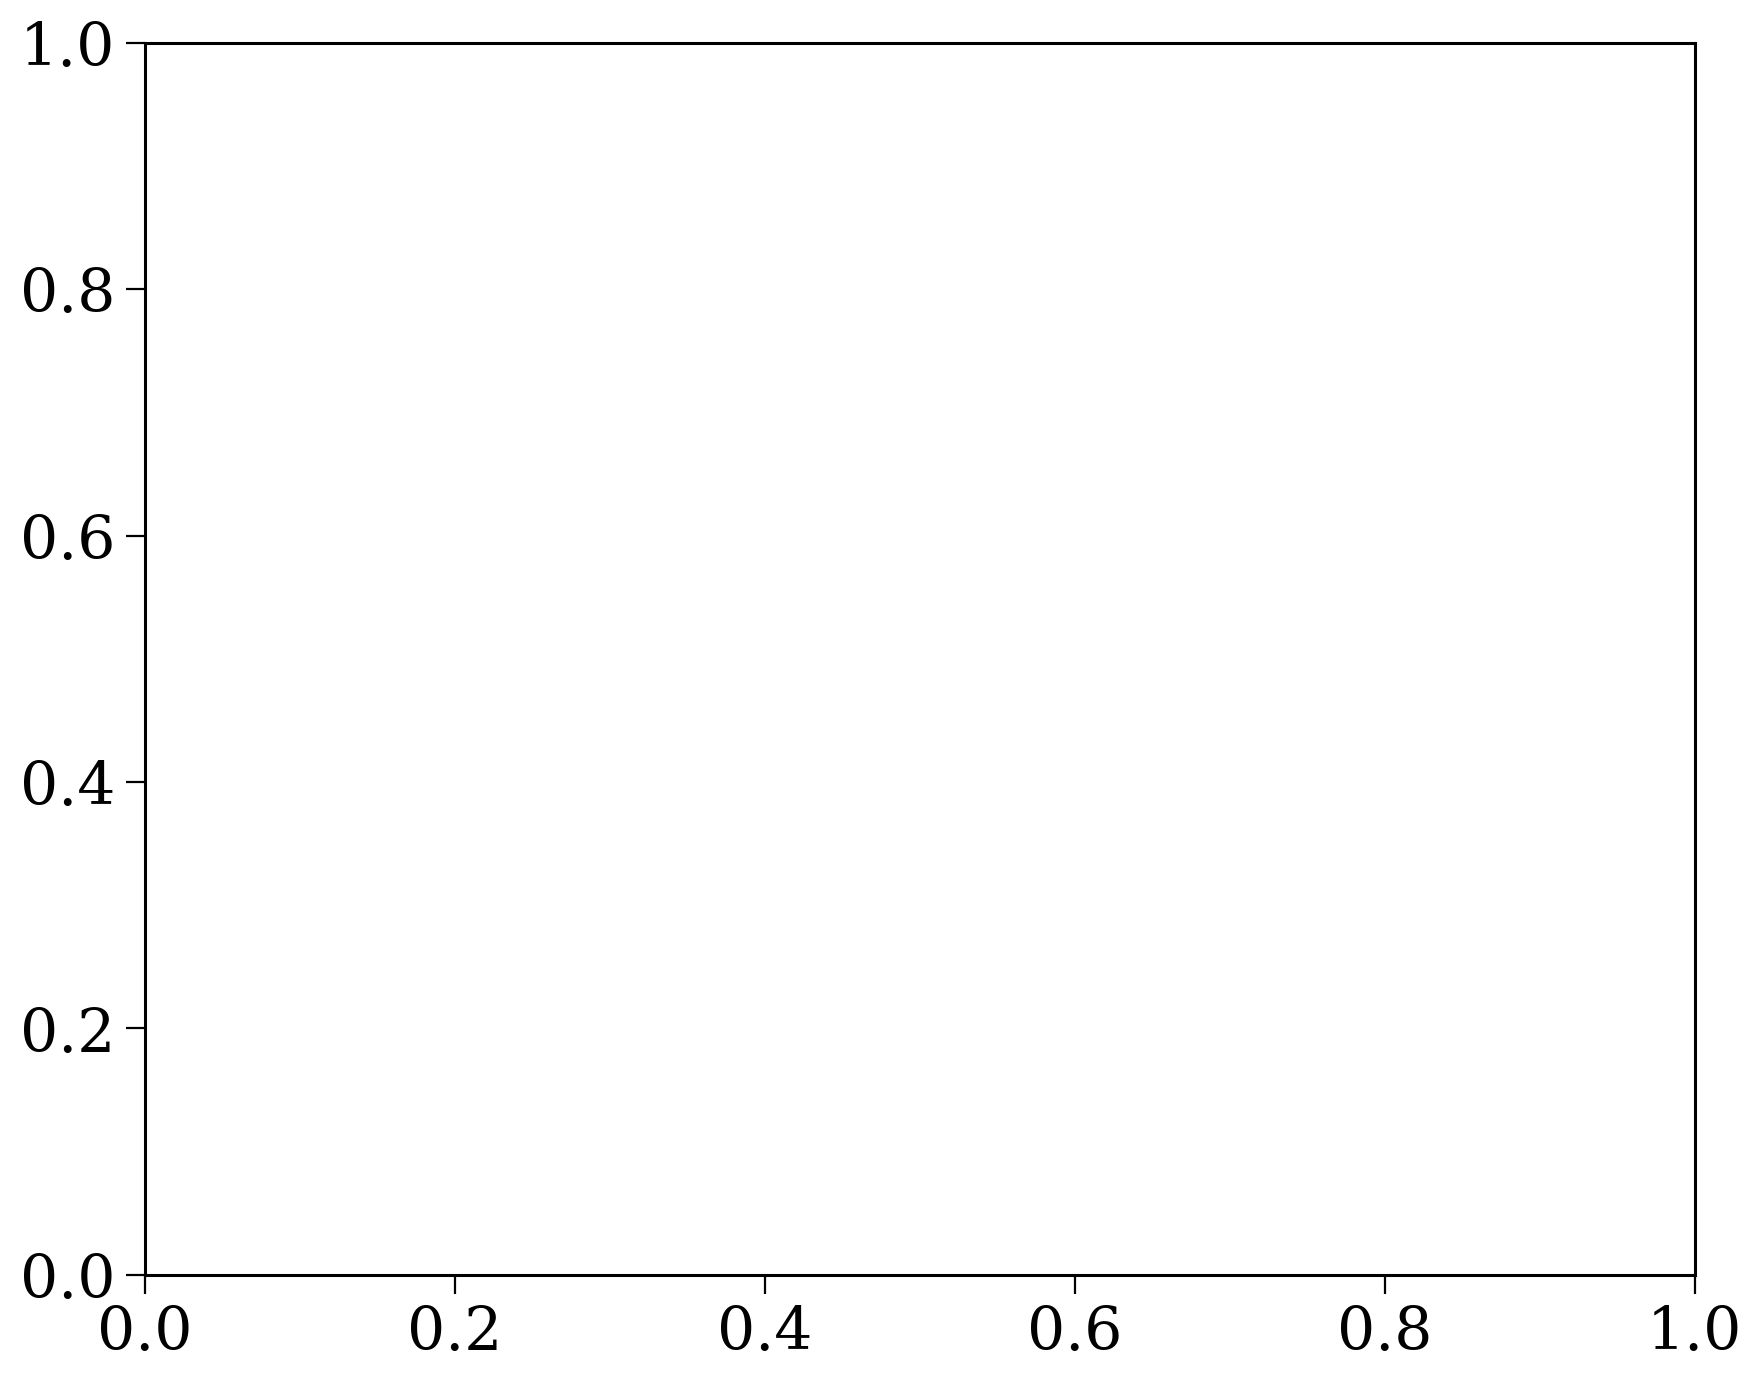

In [38]:
fig, ax = plt.subplots(figsize=(10, 8))

colours = final_bpp["SN_1"].map({0: plt.get_cmap("viridis")(0), 1: plt.get_cmap("viridis")(0.5), 2: plt.get_cmap("magma")(0.6)}).values
colours = final_bpp["kstar_1"] == 12

ax.scatter(initC["metallicity"], initC["mass_1"],
           c=colours,
           s=12,
           rasterized=True)

ax.plot(min_exploding_mass["metallicity"], min_exploding_mass["mass_1"],
        c='black', lw=5)

# ax.axhspan(max(mass_range) + mass_step, 100, color=cogsworth.utils.kstar_translator[13]["colour"])
# ax.axhspan(0, min(mass_range) - mass_step, color=cogsworth.utils.kstar_translator[12]["colour"])

# ax.annotate('No Core-Collapse', xy=(0.5, 0.01), xycoords='axes fraction',
#             fontsize=0.5*fs, color='white', ha='center', va='bottom')
# ax.annotate('All Core-Collapse', xy=(0.5, 0.99), xycoords='axes fraction',
#             fontsize=0.5*fs, color='white', ha='center', va='top')

# for k in np.unique(final_bpp['kstar_1']):
#     ax.scatter(
#         np.nan, np.nan,
#         c=cogsworth.utils.kstar_translator[k]["colour"],
#         label=cogsworth.utils.kstar_translator[k]["short"],
#     )

for sn_type, color in zip([0, 1, 2], [plt.get_cmap("viridis")(0), plt.get_cmap("viridis")(0.5), plt.get_cmap("magma")(0.6)]):
    ax.scatter(
        np.nan, np.nan,
        c=color,
        label={0: "No SN", 1: "Core-Collapse SN", 2: "ECSN"}[sn_type],
    )


Z_range = np.geomspace(1e-4, 0.03, 1000)
line = np.log10(Z_range) * 1.1 + 10.1
line[Z_range < 1.05e-3] = 6.825
plt.plot(Z_range, line, c='white', ls='--', label="CCSN Fit")

line = np.log10(Z_range) * 1.1 + 10.1
line[(Z_range < 1.05e-3)] = np.log10(Z_range)[(Z_range < 1.05e-3)] * 0.8 + 9.2
line[Z_range < 3e-4] = 6.38
plt.plot(Z_range, line, c='white', ls=':', label="Any SN Fit")

ax.legend(loc='center left', handletextpad=0.0)

ax.set(
    xlabel="Metallicity",
    ylabel="Initial Mass (M$_\odot$)",
    xscale="log",
    xlim=(1e-4, 0.03),
    ylim=(6, 9),
)

# plt.savefig("../plots/cosmic_explode_crit.pdf", format="pdf", bbox_inches='tight')
plt.show()